# 911 Calls Capstone Project

For this capstone project, we will analyze some 911 call data from [Kaggle](https://www.kaggle.com/mchirico/montcoalert). The data contains the following fields:

* lat :			String variable, Latitude
* lng:			String variable, Longitude
* desc:			String variable, Description of the Emergency Call
* zip:			String variable, Zipcode
* title:		String variable, Title
* timeStamp:	String variable, YYYY-MM-DD HH:MM:SS
* twp: 			String variable, Township
* addr: 		String variable, Address
* e: 			String variable, Dummy variable (always 1)

Simply follow along with this notebook and try to complete the instructions or answer the questions in bold using your Python and Data Science skills!

## Data and Setup
____

**Import numpy and pandas**

In [43]:
import numpy as np
import pandas as pd

pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

**Import the visualization libraries and set %matplotlib inline.**

In [44]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


# **Read the csv file as a dataframe called df**

In [45]:
df = pd.read_csv('911.csv')

**Check the info() of the dataframe**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


** Check the head of df **

In [47]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station 332; 2015-12-10 @ 17:10:52;,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP; Station 345; 2015-12-10 @ 17:29:21;,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-Station:STA27;,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A; 2015-12-10 @ 16:47:36;,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; Station 329; 2015-12-10 @ 16:56:52;,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


## Basic Questions

**What are the top 5 zip codes for 911 calls?**

In [48]:
df['zip'].value_counts().head(5)

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

**What are the top 5 townships (twp) for 911 calls?**

In [49]:
df['twp'].value_counts().head(5)

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

Take a look at the 'title' column. How many unique title codes are there?

In [50]:
df['title'].nunique()

110

## Creating New Features

In the title column, there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. Use .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.

For example, if the value of the title column is EMS: BACK PAINS/INJURY, the value of the Reason column would be EMS.

In [51]:
df['Reason'] = df['title'].apply(lambda x: x.split(':')[0])

**What is the most common reason for a 911 call based on this new column?**

In [52]:
df['Reason'].value_counts()

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

**Now use seaborn to create a count plot of 911 calls by Reason.**

<Axes: xlabel='Reason', ylabel='count'>

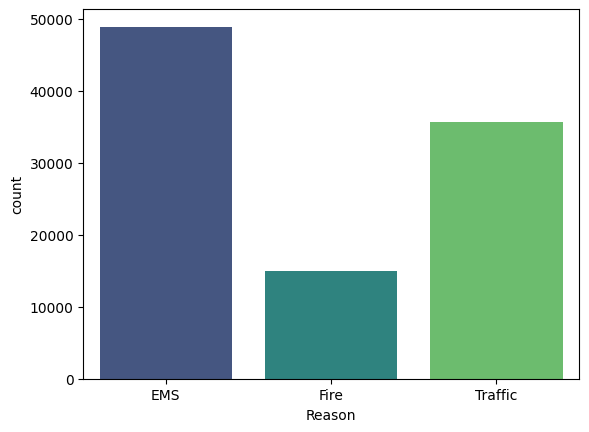

In [53]:
sns.countplot(x='Reason', data=df, hue='Reason', palette='viridis', legend=False)

___

**Now let's focus on the time information. What is the data type of the objects in the timeStamp column?**

In [54]:
df.dtypes['timeStamp']

dtype('O')

In [55]:
df.dtypes

lat          float64
lng          float64
desc          object
zip          float64
title         object
timeStamp     object
twp           object
addr          object
e              int64
Reason        object
dtype: object

**You should have noticed that these timestamps are still strings. Use [pd.to_datetime](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.to_datetime.html) to convert the column of strings to DateTime objects.**

In [56]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
df['timeStamp'].head()

0   2015-12-10 17:40:00
1   2015-12-10 17:40:00
2   2015-12-10 17:40:00
3   2015-12-10 17:40:01
4   2015-12-10 17:40:01
Name: timeStamp, dtype: datetime64[ns]

**You can now retrieve specific attributes of a DateTime object by calling them. For example:**

    time = df['timeStamp'].iloc[0]
    time.hour

**You can use Jupyter's tab method to explore the different attributes you can call. Now that the timestamp column is actually DateTime objects, use .apply() to create 3 new columns called Hour, Month, and Day of Week. You will create these columns based on the timeStamp column. Refer to the solutions if you get stuck on this step.**

In [57]:
df["timeStamp"]

0       2015-12-10 17:40:00
1       2015-12-10 17:40:00
2       2015-12-10 17:40:00
3       2015-12-10 17:40:01
4       2015-12-10 17:40:01
                ...        
99487   2016-08-24 11:06:00
99488   2016-08-24 11:07:02
99489   2016-08-24 11:12:00
99490   2016-08-24 11:17:01
99491   2016-08-24 11:17:02
Name: timeStamp, Length: 99492, dtype: datetime64[ns]

In [58]:
df["Hours"] = df['timeStamp'].apply(lambda x: x.hour)
df["Month"] = df['timeStamp'].apply(lambda x: x.month)
df["Day of Week"] = df['timeStamp'].apply(lambda x: x.dayofweek)
df[['timeStamp', 'Hours', 'Month', 'Day of Week']].head()

,timeStamp,Hours,Month,Day of Week
0,2015-12-10 17:40:00,17,12,3
1,2015-12-10 17:40:00,17,12,3
2,2015-12-10 17:40:00,17,12,3
3,2015-12-10 17:40:01,17,12,3
4,2015-12-10 17:40:01,17,12,3


**Notice that the day of the week is an integer between 0 and 6. Use .map() with this dictionary to map the actual string names to the day of the week:**

    dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [59]:
df["Day of Week"].unique()

array([3, 4, 5, 6, 0, 1, 2])

In [60]:
dmap = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
df['Day of Week'] = df['Day of Week'].map(dmap)

In [61]:
df[["Hours", "Month", "Day of Week"]].head()

,Hours,Month,Day of Week
0,17,12,Thu
1,17,12,Thu
2,17,12,Thu
3,17,12,Thu
4,17,12,Thu


Now use seaborn to create a count plot of the 'Day of Week' column with the hue based on the 'Reason' column.

<Axes: xlabel='Day of Week', ylabel='count'>

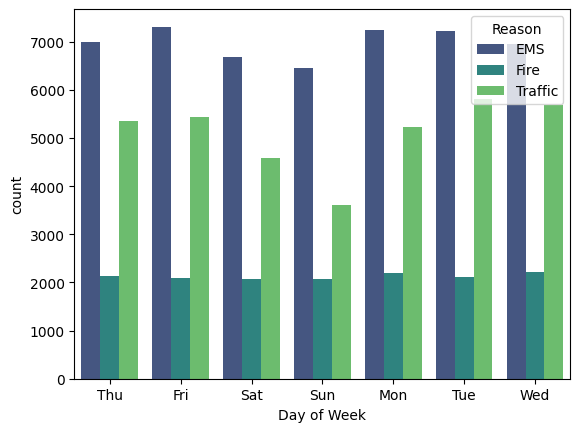

In [62]:
sns.countplot(x='Day of Week', data=df, hue='Reason', palette='viridis')

Now do the same thing for Month:

<Axes: xlabel='Month', ylabel='count'>

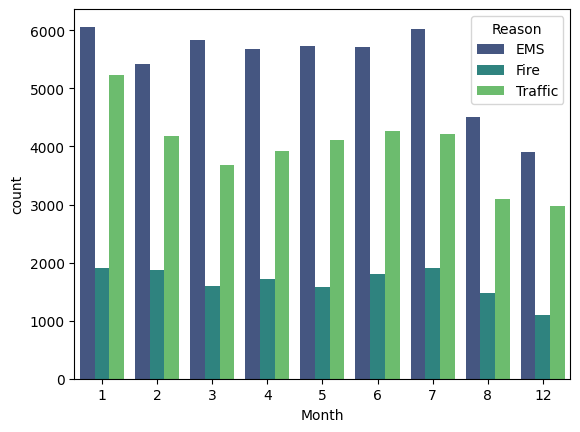

In [63]:
sns.countplot(x='Month', data=df, hue='Reason', palette='viridis')

Did you notice something strange about the plot?

_____

You should have noticed that some months were missing. Let's see if we can perhaps fill in this information by plotting the information in a different way, possibly a simple line plot that fills in the missing months. To do this, we'll need to work with pandas...

Now create a groupby object called byMonth, where you group the DataFrame by the Month column and use the count() method for aggregation. Use the head() method on this returned DataFrame.

In [64]:
byMonth = df.groupby('Month')

countByMonth = byMonth.count()
countByMonth.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hours,Day of Week
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423


Now create a simple plot from the DataFrame showing the number of calls per month.

<Axes: xlabel='Month'>

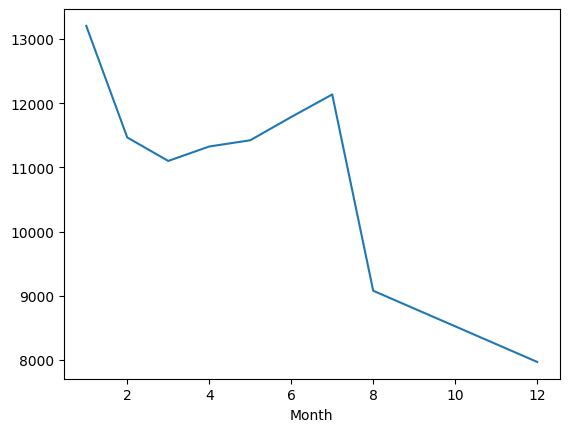

In [65]:
countByMonth['lat'].plot()

Now see if you can use Seaborn's lmplot() to create a linear fit on the number of calls per month. Keep in mind that you may need to reset the index to a column.

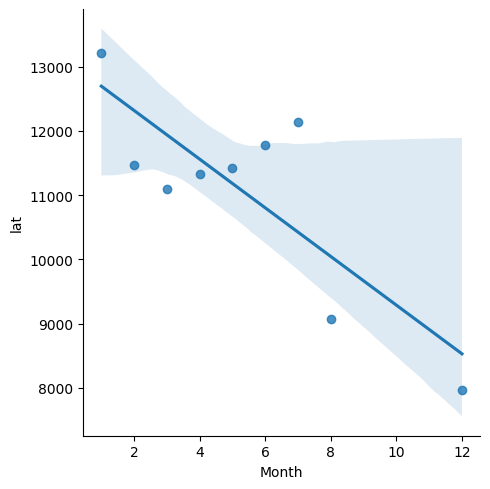

In [66]:
sns.lmplot(x="Month", y="lat", data=countByMonth.reset_index())

Create a new column called "Date" that contains the date from the timeStamp column. You will need to use apply along with the .date() method.

In [67]:
df['Date'] = df['timeStamp'].apply(lambda x: x.date())
df['Date'].head()

0    2015-12-10
1    2015-12-10
2    2015-12-10
3    2015-12-10
4    2015-12-10
Name: Date, dtype: object

Now group this Date column with the count() aggregate and create a plot of the number of 911 calls.

<Axes: xlabel='Date'>

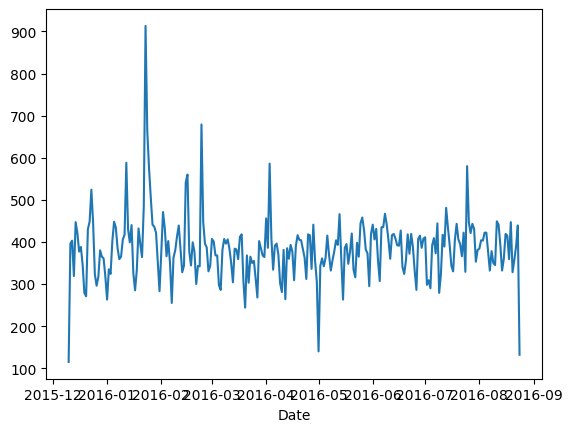

In [68]:
group_by_date = df.groupby('Date').count()
group_by_date['lat'].plot()

Now recreate this plot but create 3 separate plots, each plot representing a reason for the 911 call

<Axes: xlabel='Date'>

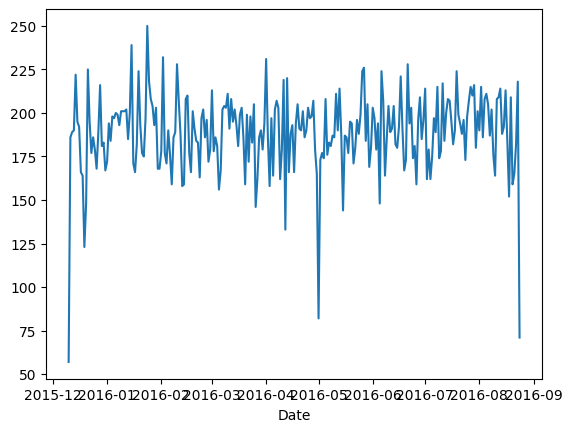

In [69]:
group_by_date = df.loc[df["Reason"] == "EMS"].groupby("Date").count()
group_by_date["lat"].plot()

<Axes: xlabel='Date'>

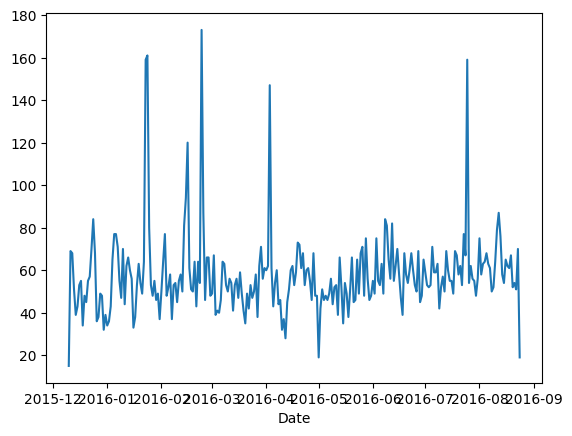

In [70]:
group_by_date = df.loc[df["Reason"] == "Fire"].groupby("Date").count()
group_by_date["lat"].plot()

<Axes: xlabel='Date'>

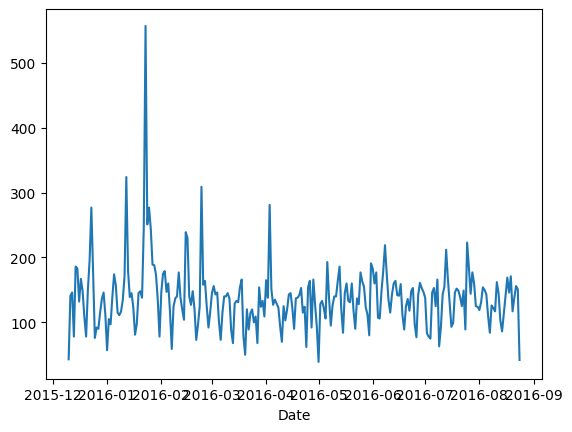

In [71]:
group_by_date = df.loc[df["Reason"] == "Traffic"].groupby("Date").count()
group_by_date["lat"].plot()

Now let's move on to creating heatmaps with seaborn and our data. We'll first need to restructure the dataframe so that the columns become the hours and the index becomes the day of the week. 

In [72]:
df_pivot = pd.pivot_table(df, index="Day of Week", columns="Hours", values="lat", aggfunc="count")
df_pivot.head()

Hours,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354


Now create a HeatMap using this new DataFrame.

<Axes: xlabel='Hours', ylabel='Day of Week'>

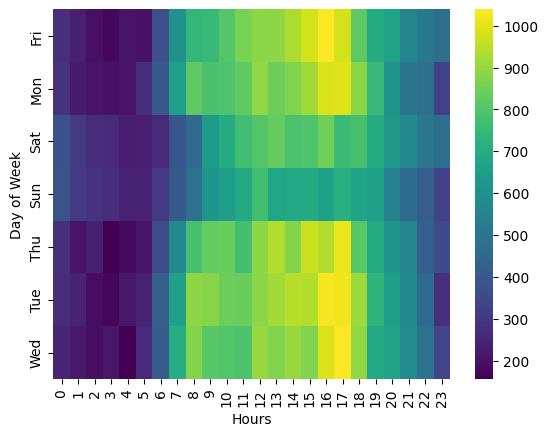

In [73]:
sns.heatmap(df_pivot, cmap="viridis")

Now create a clustermap using this DataFrame.

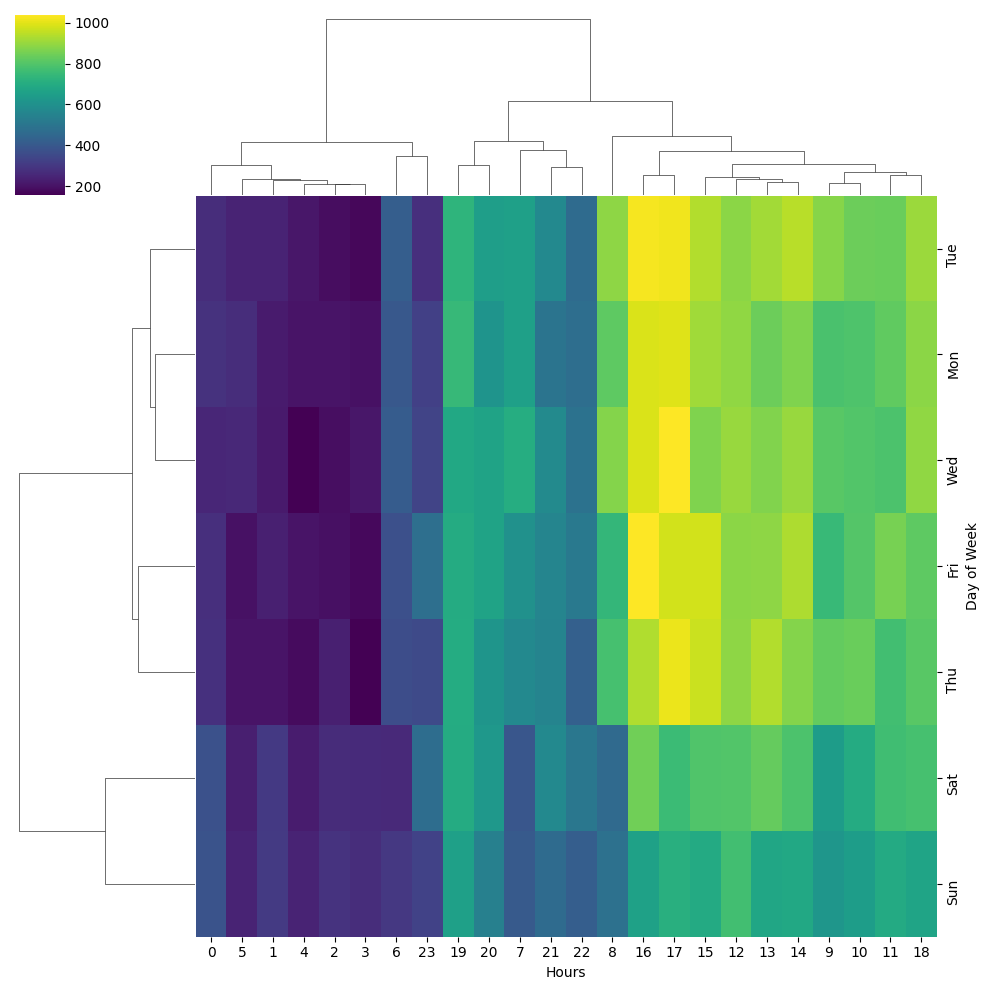

In [74]:
sns.clustermap(df_pivot, cmap="viridis")

Now repeat these same plots and operations for a DataFrame that displays the month as a column.

In [75]:
df_pivot = pd.pivot_table(df, index="Day of Week", columns="Month", values="lat", aggfunc="count")
df_pivot.head()

Month,1,2,3,4,5,6,7,8,12
Day of Week,,,,,,,,,
Fri,1970,1581,1525,1958,1730,1649,2045,1310,1065
Mon,1727,1964,1535,1598,1779,1617,1692,1511,1257
Sat,2291,1441,1266,1734,1444,1388,1695,1099,978
Sun,1960,1229,1102,1488,1424,1333,1672,1021,907
Thu,1584,1596,1900,1601,1590,2065,1646,1230,1266


<Axes: xlabel='Month', ylabel='Day of Week'>

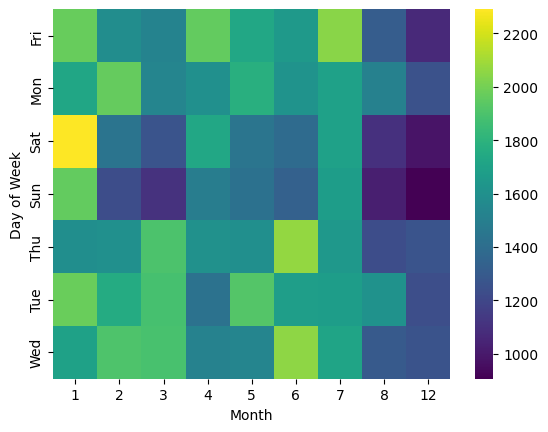

In [76]:
sns.heatmap(df_pivot, cmap="viridis")

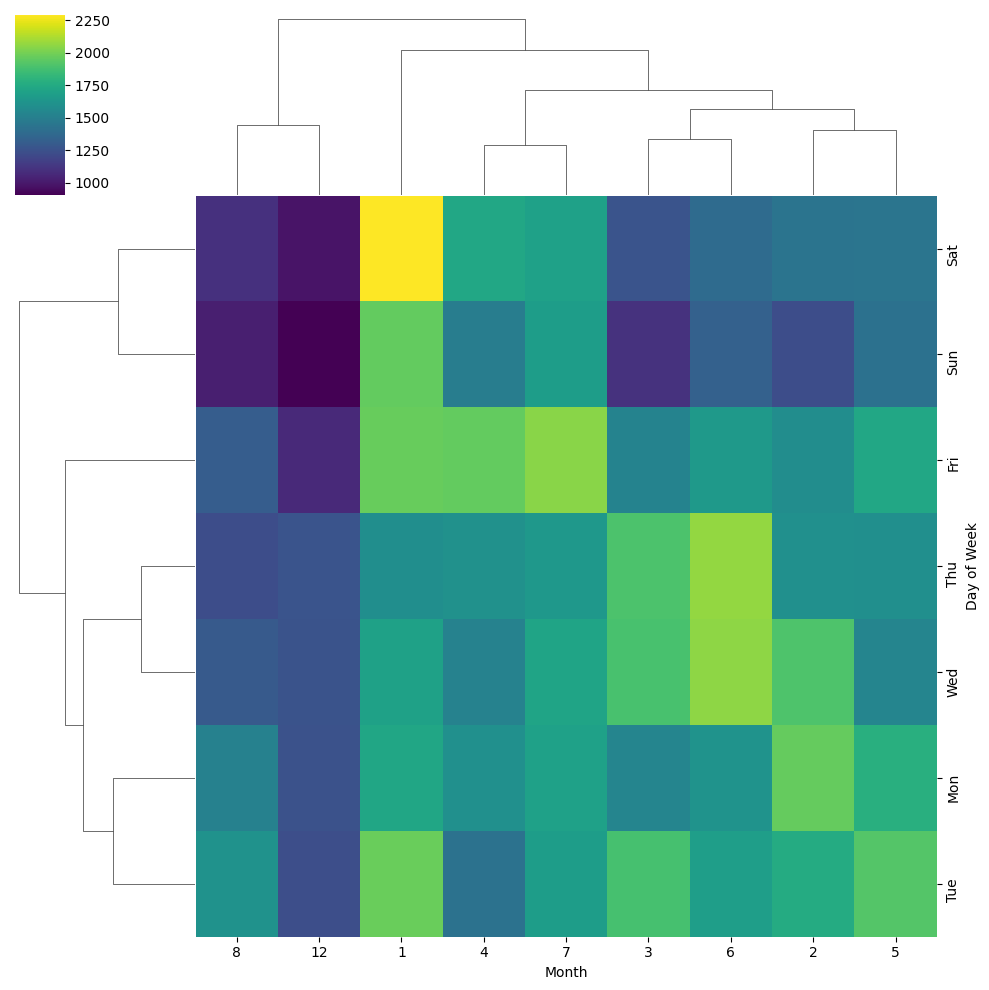

In [77]:
sns.clustermap(df_pivot, cmap="viridis")

Continue exploring the data as you see fit!